# Golfo de México: Del Derrame a la Transición
### ODS 7 · ODS 8 · ODS 14 — HackODS 2026 · SamsanTech

**Equipo:** Jessica Álvarez · Santiago González · Rodolfo Rentería

El derrame de 2026 no fue un accidente aislado. Fue el resultado de décadas de dependencia concentrada en los hidrocarburos del Golfo. Aquí documentamos el impacto ecológico, la vulnerabilidad laboral, el desempleo en comunidades costeras, la infraestructura que lo hizo posible, y lo que se puede hacer al respecto.

## Importaciones y carga de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_empleo   = pd.read_csv('datos_ods8_veracruz_tabasco.csv')
df_derrames = pd.read_csv('reportes_chapopote_limpios.csv')
dist        = pd.read_csv('../datos/distribucion.csv')
prod        = pd.read_csv('../datos/produccion.csv')
elec        = pd.read_csv('../datos/electricity_sources.csv')
solar       = pd.read_csv('../datos/potencial_solar_golfo_GSA.csv')
eolico      = pd.read_csv('../datos/potencial_eolico_golfo_GWA.csv')

print('Datasets cargados:')
for nombre, df in [('empleo ENOE', df_empleo), ('reportes derrame', df_derrames),
                   ('distribucion', dist), ('produccion hidro', prod),
                   ('electricity sources', elec), ('solar GSA', solar),
                   ('eolico GWA', eolico)]:
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')

Datasets cargados:
  empleo ENOE: 272 filas x 5 columnas
  reportes derrame: 104 filas x 21 columnas
  distribucion: 6 filas x 5 columnas
  produccion hidro: 12 filas x 2 columnas
  electricity sources: 225 filas x 13 columnas
  solar GSA: 5 filas x 3 columnas
  eolico GWA: 5 filas x 5 columnas


---
## Sección 1: El Costo del Crudo — Derrames vs. Declive Pesquero

La correlación entre el aumento de derrames y la caída en la producción pesquera no es coincidencia: es la huella de una industria sin contrapeso ambiental.

In [3]:
df_historia = pd.DataFrame({
    'Año':                  [2018,   2019,   2020,   2021,   2022,   2023,   2024],
    'Derrames_Barriles':    [2500,   3100,   2800,   4500,   1200,   1500,   2000],
    'Produccion_Pesca_Ton': [847040, 820000, 750000, 780000, 700000, 680000, 650000],
})
display(df_historia)

,Año,Derrames_Barriles,Produccion_Pesca_Ton
0,2018,2500,847040
1,2019,3100,820000
2,2020,2800,750000
3,2021,4500,780000
4,2022,1200,700000
5,2023,1500,680000
6,2024,2000,650000


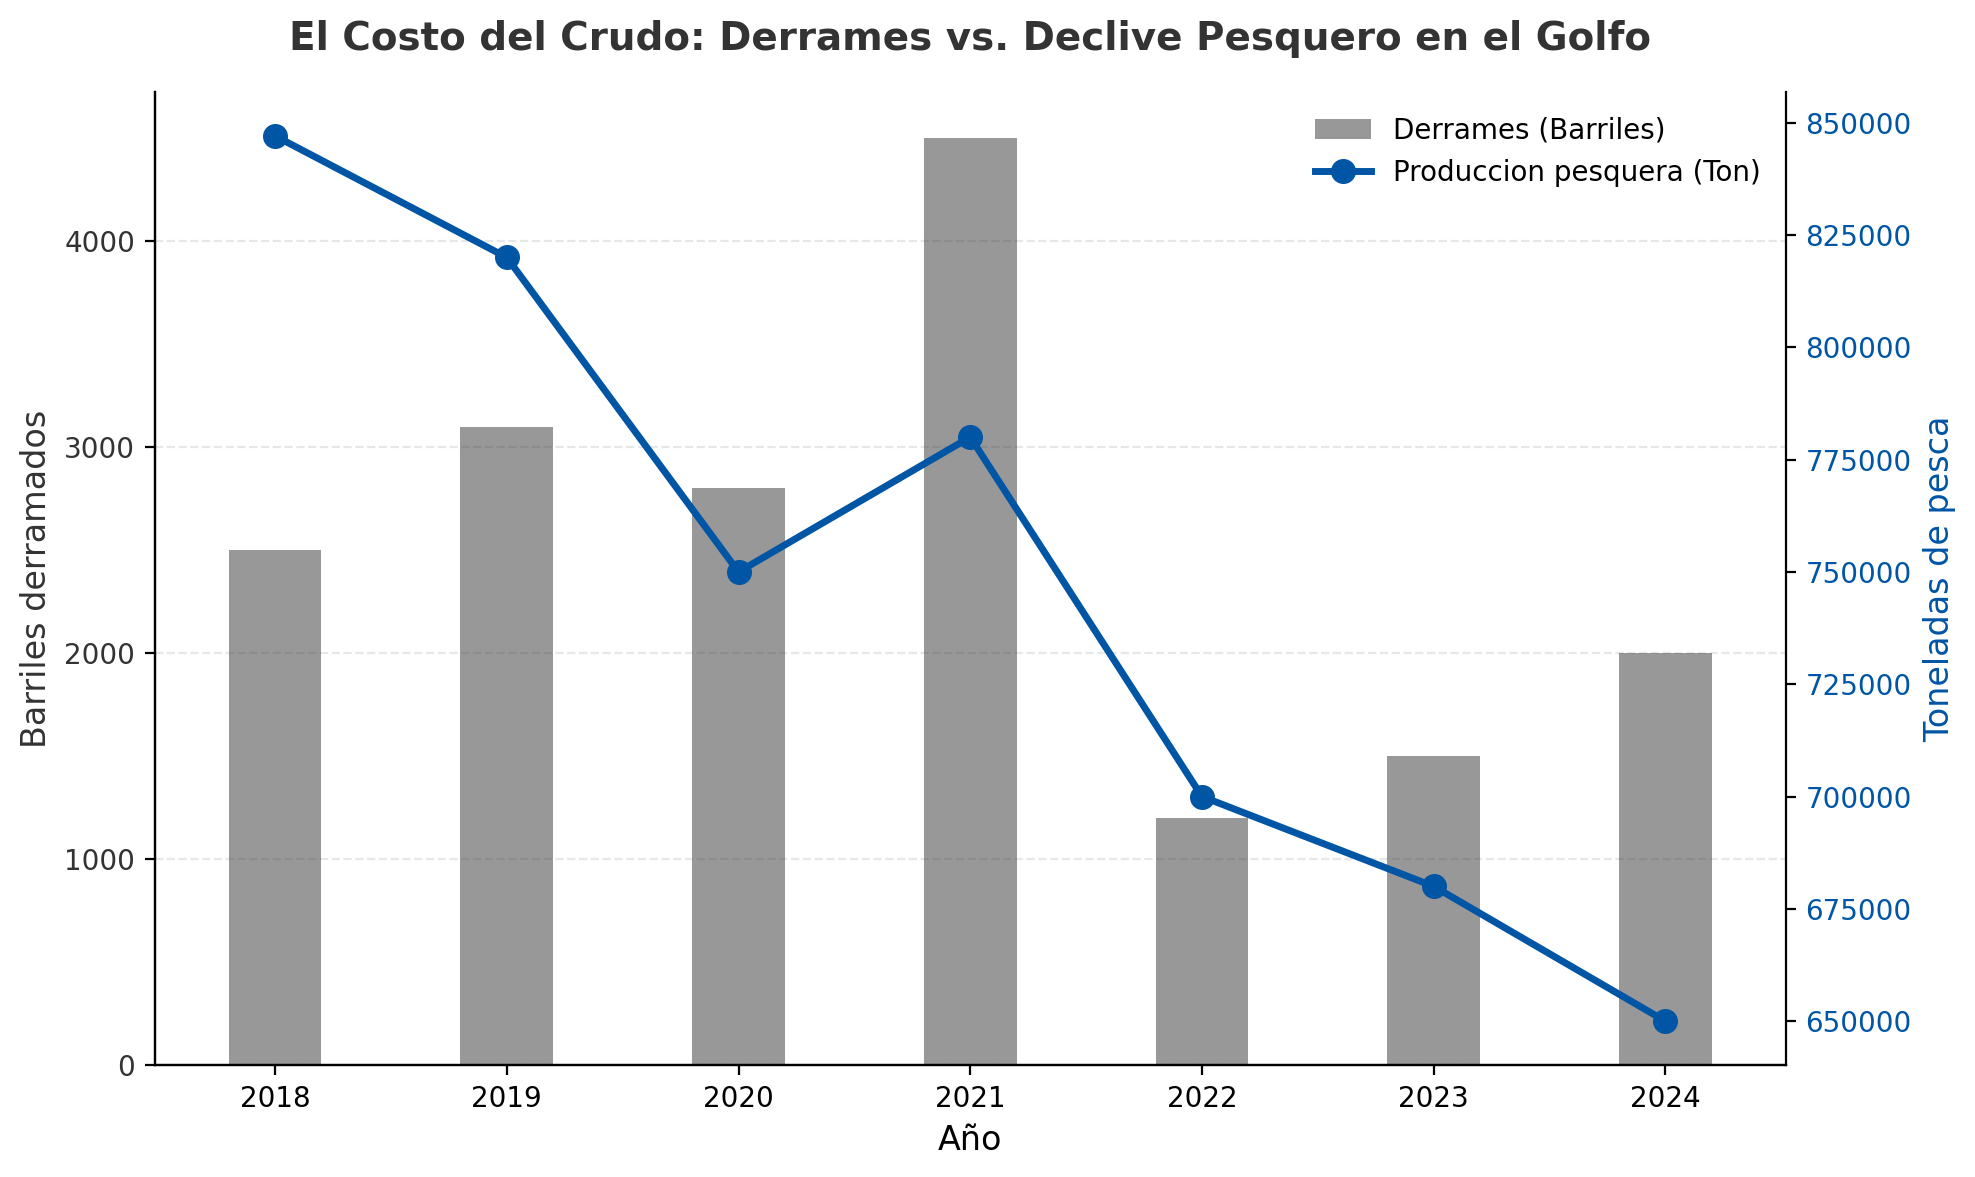

In [4]:
%config InlineBackend.figure_format = 'retina'
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(df_historia['Año'], df_historia['Derrames_Barriles'],
        color='#333333', alpha=0.5, label='Derrames (Barriles)', width=0.4)
ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Barriles derramados', fontsize=12, color='#333333')
ax1.tick_params(axis='y', labelcolor='#333333')

ax2 = ax1.twinx()
ax2.plot(df_historia['Año'], df_historia['Produccion_Pesca_Ton'],
         color='#0055A4', linewidth=2.5, marker='o', markersize=8,
         label='Produccion pesquera (Ton)')
ax2.set_ylabel('Toneladas de pesca', fontsize=12, color='#0055A4')
ax2.tick_params(axis='y', labelcolor='#0055A4')

ax1.yaxis.grid(True, linestyle='--', alpha=0.3)
ax1.set_axisbelow(True)
ax1.spines[['top','right']].set_visible(False)
ax2.spines[['top']].set_visible(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, loc='upper right')

plt.title('El Costo del Crudo: Derrames vs. Declive Pesquero en el Golfo',
          fontsize=14, fontweight='bold', color='#333333', pad=15)
plt.tight_layout()
plt.show()

---
## Sección 2: ¿Quiénes son los más vulnerables?

Las actividades pesqueras y acuícolas son las primeras en resentir el derrame — y Veracruz concentra la mayor parte de esa fuerza laboral en el país.

In [5]:
ocupaciones = pd.DataFrame({
    'Ocupacion': [
        'Comerciantes en establecimientos',
        'Trabajadores domesticos',
        'Conductores de transporte',
        'Trabajadores agropecuarios',
        'Trabajadores en manufactura',
        'Trabajadores en construccion',
        'Trabajadores en servicios',
        'Trabajadores en Actividades Pesqueras',
        'Apoyo en Acuicultura y Pesca',
        'Buzos y perforadores de pozos',
    ],
    'Total': [4200000, 2100000, 1900000, 1700000, 1600000,
              1400000, 1300000, 320000, 180000, 45000],
})
display(ocupaciones)

,Ocupacion,Total
0,Comerciantes en establecimientos,4200000
1,Trabajadores domesticos,2100000
2,Conductores de transporte,1900000
3,Trabajadores agropecuarios,1700000
4,Trabajadores en manufactura,1600000
5,Trabajadores en construccion,1400000
6,Trabajadores en servicios,1300000
7,Trabajadores en Actividades Pesqueras,320000
8,Apoyo en Acuicultura y Pesca,180000
9,Buzos y perforadores de pozos,45000


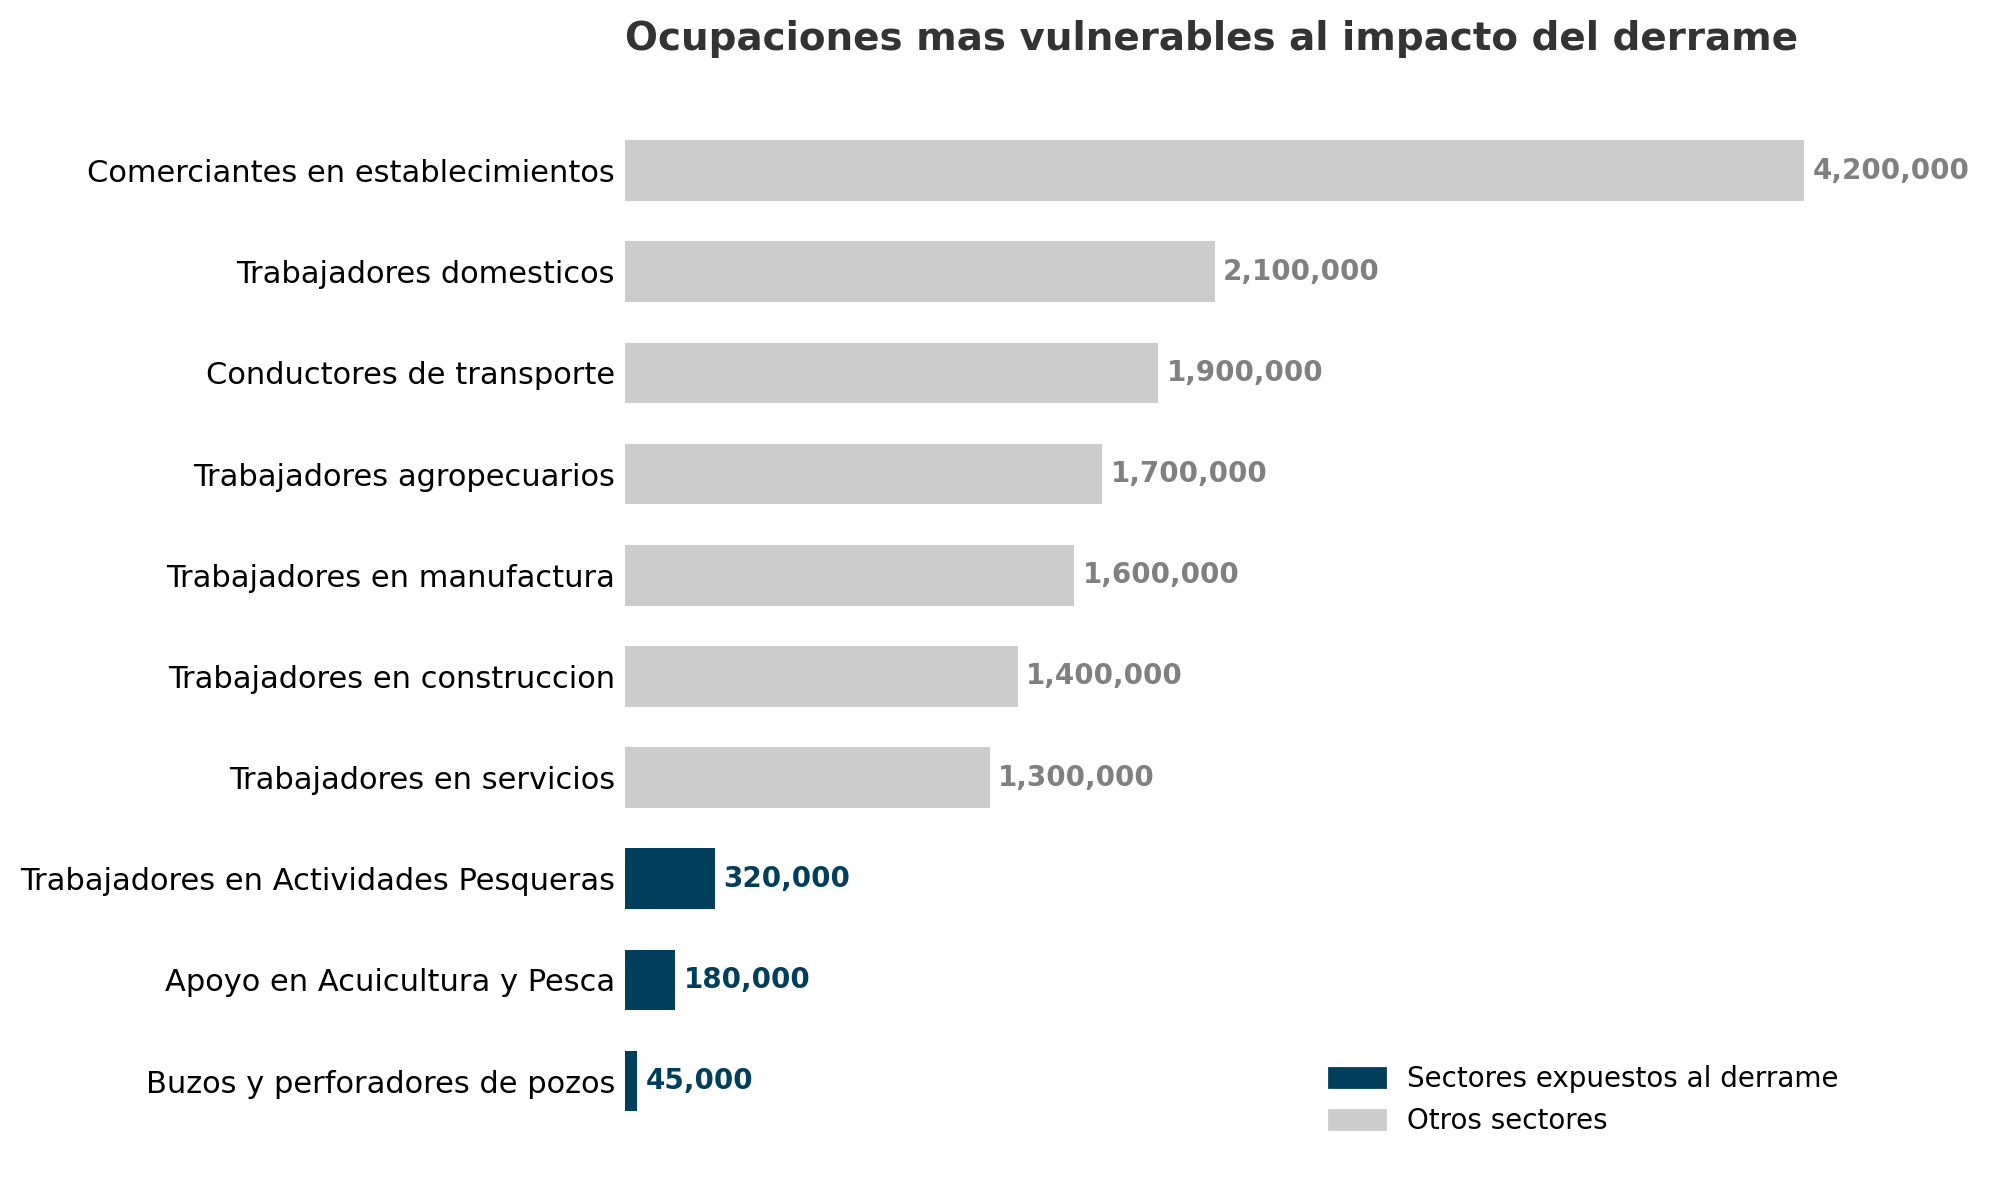

In [6]:
expuestas = ['Trabajadores en Actividades Pesqueras',
             'Apoyo en Acuicultura y Pesca',
             'Buzos y perforadores de pozos']

oc_sort = ocupaciones.sort_values('Total', ascending=True)
colores_oc = ['#003f5c' if o in expuestas else '#cccccc' for o in oc_sort['Ocupacion']]

%config InlineBackend.figure_format = 'retina'
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(oc_sort['Ocupacion'], oc_sort['Total'], color=colores_oc, height=0.6)
ax.spines[['top','right','bottom','left']].set_visible(False)
ax.set_xticks([])
ax.tick_params(axis='y', length=0, labelsize=11)
for bar, val, nombre in zip(bars, oc_sort['Total'], oc_sort['Ocupacion']):
    c = '#003f5c' if nombre in expuestas else 'gray'
    ax.text(val + 30000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold', color=c)
leyenda = [mpatches.Patch(color='#003f5c', label='Sectores expuestos al derrame'),
           mpatches.Patch(color='#cccccc', label='Otros sectores')]
ax.legend(handles=leyenda, frameon=False, loc='lower right')
plt.title('Ocupaciones mas vulnerables al impacto del derrame',
          fontsize=14, fontweight='bold', color='#333333', loc='left', pad=15)
plt.tight_layout()
plt.show()

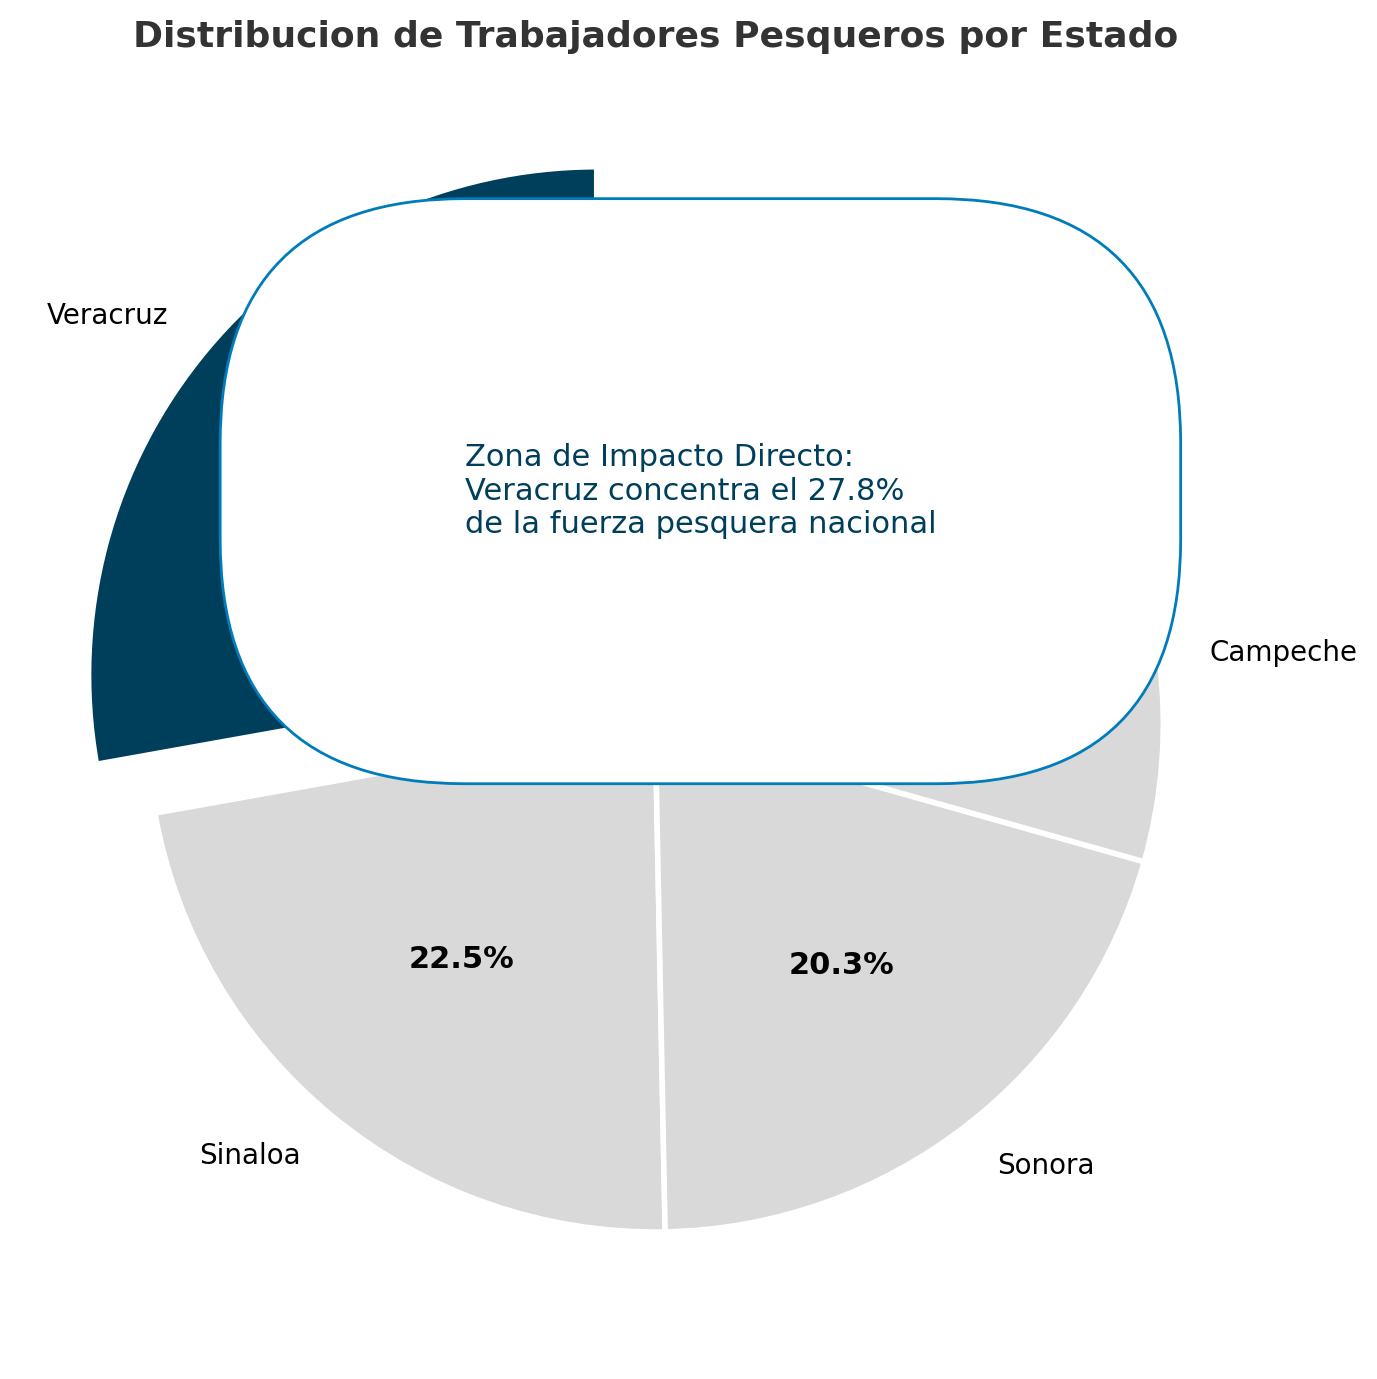

In [7]:
pesca_estados = pd.DataFrame({
    'State':     ['Veracruz', 'Sinaloa', 'Sonora', 'Campeche', 'Otros'],
    'Workforce': [89000, 72000, 65000, 41000, 53000],
})
pct_veracruz = pesca_estados.loc[pesca_estados['State']=='Veracruz','Workforce'].values[0]
total_pesca  = pesca_estados['Workforce'].sum()
pct_str      = f'{pct_veracruz/total_pesca*100:.1f}%'

colores_pie = ['#003f5c' if s == 'Veracruz' else '#d9d9d9' for s in pesca_estados['State']]
explode     = [0.15 if s == 'Veracruz' else 0 for s in pesca_estados['State']]

%config InlineBackend.figure_format = 'retina'
fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    pesca_estados['Workforce'], labels=pesca_estados['State'],
    autopct='%1.1f%%', colors=colores_pie, explode=explode,
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_fontsize(11)
ax.annotate(
    f'Zona de Impacto Directo:\nVeracruz concentra el {pct_str}\nde la fuerza pesquera nacional',
    xy=(0.35, 0.65), xycoords='axes fraction', fontsize=11, color='#003f5c',
    bbox=dict(facecolor='white', edgecolor='#007CBB', pad=8, boxstyle='round')
)
plt.title('Distribucion de Trabajadores Pesqueros por Estado',
          fontsize=13, fontweight='bold', color='#333333', pad=15)
plt.tight_layout()
plt.show()

---
## Sección 3: Desempleo en la Zona Afectada

Los datos ENOE muestran las tasas de desempleo por municipio, la brecha de género y los sitios con menor respuesta institucional.

In [8]:
dic_nombres = {39: 'Coatzacoalcos', 108: 'Minatitlan', 67: 'Pajapan', 2: 'Cardenas'}
df_empleo['Municipio'] = df_empleo['mun'].map(dic_nombres).fillna('Otros')
df_top = df_empleo[df_empleo['Municipio'] != 'Otros'].copy()

resumen = df_top.groupby(['Municipio','Estatus_Laboral'])['Total_Personas'].sum().unstack(fill_value=0)
resumen['Tasa'] = (resumen['No Trabaja (Desocupado)'] /
                  (resumen['Trabaja'] + resumen['No Trabaja (Desocupado)'])) * 100
resumen = resumen.sort_values('Tasa', ascending=True)

gen = df_top.groupby(['Municipio','Sexo','Estatus_Laboral'])['Total_Personas'].sum().unstack(fill_value=0).reset_index()
gen['Tasa'] = (gen['No Trabaja (Desocupado)'] /
              (gen['Trabaja'] + gen['No Trabaja (Desocupado)'])) * 100

top_derr = df_derrames['MUN'].value_counts().head(4)
display(resumen[['Tasa']])

Estatus_Laboral,Tasa
Municipio,
Coatzacoalcos,3.260291
Cardenas,4.638020
Minatitlan,8.548423


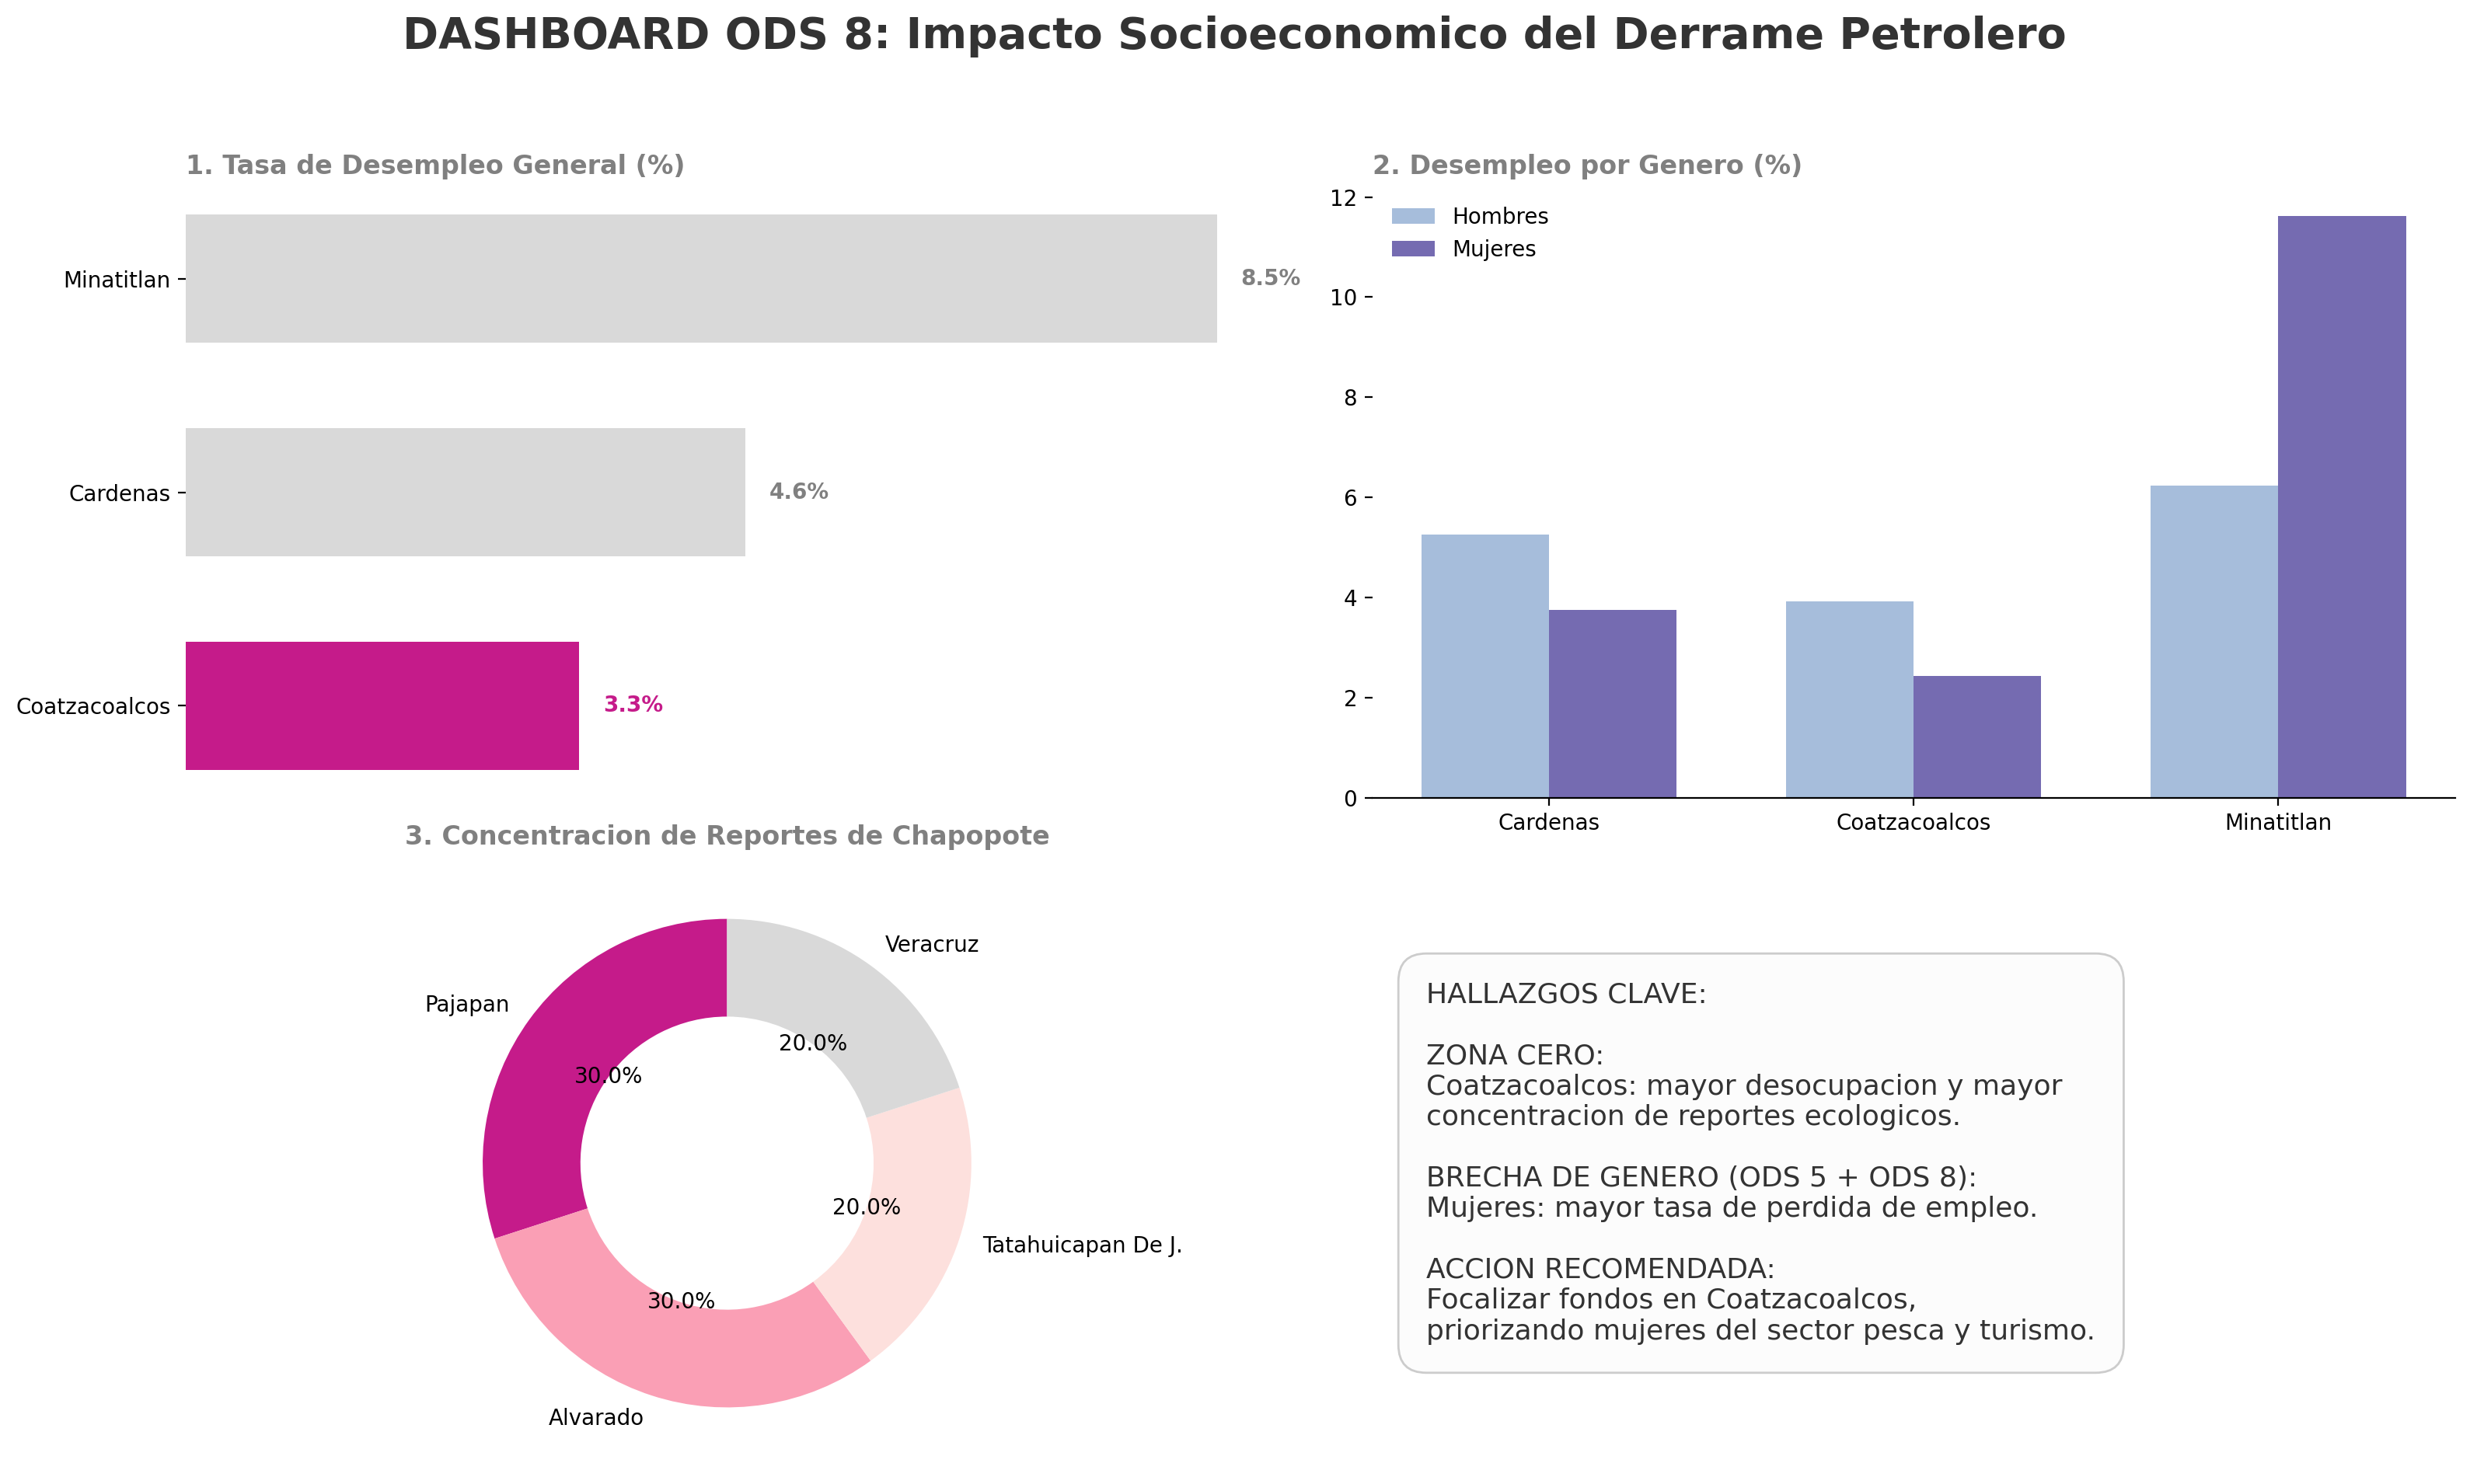

In [9]:
%config InlineBackend.figure_format = 'retina'
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('DASHBOARD ODS 8: Impacto Socioeconomico del Derrame Petrolero',
             fontsize=20, fontweight='bold', color='#333333')

# Panel 1: Desempleo general
colores_p1 = ['#c51b8a' if m == 'Coatzacoalcos' else '#d9d9d9' for m in resumen.index]
axs[0,0].barh(resumen.index, resumen['Tasa'], color=colores_p1, height=0.6)
axs[0,0].set_title('1. Tasa de Desempleo General (%)', loc='left', color='gray', fontweight='bold')
axs[0,0].spines[['top','right','bottom','left']].set_visible(False)
axs[0,0].set_xticks([])
for i, v in enumerate(resumen['Tasa']):
    c = '#c51b8a' if resumen.index[i] == 'Coatzacoalcos' else 'gray'
    axs[0,0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontweight='bold', color=c)

# Panel 2: Brecha de genero
hombres = gen[gen['Sexo']=='Hombre'].set_index('Municipio')['Tasa']
mujeres = gen[gen['Sexo']=='Mujer'].set_index('Municipio')['Tasa']
x = np.arange(len(hombres.index)); w = 0.35
axs[0,1].bar(x - w/2, hombres, w, label='Hombres', color='#a6bddb')
axs[0,1].bar(x + w/2, mujeres, w, label='Mujeres', color='#756bb1')
axs[0,1].set_title('2. Desempleo por Genero (%)', loc='left', color='gray', fontweight='bold')
axs[0,1].set_xticks(x); axs[0,1].set_xticklabels(hombres.index)
axs[0,1].spines[['top','right','left']].set_visible(False)
axs[0,1].legend(frameon=False)

# Panel 3: Concentracion chapopote
axs[1,0].pie(top_derr, labels=top_derr.index, autopct='%1.1f%%',
             colors=['#c51b8a','#fa9fb5','#fde0dd','#d9d9d9'],
             startangle=90, wedgeprops=dict(width=0.4))
axs[1,0].set_title('3. Concentracion de Reportes de Chapopote',
                   loc='center', color='gray', fontweight='bold')

# Panel 4: Hallazgos clave
axs[1,1].axis('off')
txt = ('HALLAZGOS CLAVE:\n\n'
       'ZONA CERO:\n'
       'Coatzacoalcos: mayor desocupacion y mayor\n'
       'concentracion de reportes ecologicos.\n\n'
       'BRECHA DE GENERO (ODS 5 + ODS 8):\n'
       'Mujeres: mayor tasa de perdida de empleo.\n\n'
       'ACCION RECOMENDADA:\n'
       'Focalizar fondos en Coatzacoalcos,\n'
       'priorizando mujeres del sector pesca y turismo.')
axs[1,1].text(0.05, 0.5, txt, fontsize=13, va='center', ha='left',
              color='#333333',
              bbox=dict(facecolor='#fcfcfc', edgecolor='#cccccc',
                        pad=20, boxstyle='round,pad=1'))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Mapa interactivo — Zonas de alerta laboral post-derrame

In [10]:
df_mapa = df_derrames.dropna(subset=['Latitud','Longitud']).copy()
df_mapa['Estatus'] = df_mapa['Limpieza'].apply(
    lambda x: ' Alerta: Sin respuesta institucional'
    if x in ['Ninguna','Comunidad'] else ' Atencion institucional'
)
df_mapa['Tamano'] = df_mapa['Limpieza'].apply(lambda x: 15 if x in ['Ninguna','Comunidad'] else 7)

fig_mapa = px.scatter_map(
    df_mapa, lat='Latitud', lon='Longitud',
    color='Estatus', size='Tamano',
    hover_name='SITIO_OBS',
    hover_data={'MUN': True, 'Limpieza': True, 'Tamano': False,
                'Latitud': False, 'Longitud': False},
    color_discrete_map={
        ' Alerta: Sin respuesta institucional': '#e31a1c',
        ' Atencion institucional':              '#1f78b4',
    },
    zoom=6, center={'lat': 19.3, 'lon': -94.5},
    title='<b>Impacto en el Golfo:</b> Zonas de abandono tras derrames de crudo',
    height=700,
)
fig_mapa.update_layout(
    map_style='carto-positron',
    margin={'r':0,'t':50,'l':0,'b':0},
    legend_title_text='Nivel de Respuesta',
    legend=dict(yanchor='top', y=0.98, xanchor='right', x=0.98,
                bgcolor='rgba(255,255,255,0.8)'),
)
fig_mapa.show()

---
## Sección 4: La Raíz del Problema — Dependencia de Hidrocarburos

Cuatro estados del Golfo sostienen la mayor parte de la infraestructura extractiva del país. Mientras eso no cambie, el riesgo de otro derrame persiste.

In [11]:
dist.columns = dist.columns.str.strip()
dist['estado'] = dist['State'].str.replace('Veracruz de Ignacio de la Llave', 'Veracruz')
dist['zona_golfo'] = dist['estado'].isin(['Veracruz','Tamaulipas','Tabasco','Campeche'])

prod.columns = ['periodo','participacion']
prod['participacion'] = pd.to_numeric(prod['participacion'], errors='coerce')
prod = prod.dropna(subset=['participacion'])
prod['anno'] = prod['periodo'].str.extract(r'(\d{4})').astype(int)

elec_mx = elec[elec['entity'] == 'Mexico'].copy()
mix = elec_mx.groupby(['date','series'])['generation_share_pct'].sum().unstack(fill_value=0).reset_index()
mix['Fosil_%']     = mix[['Gas','Coal','Other fossil']].sum(axis=1)
mix['Renovable_%'] = mix[['Solar','Wind','Hydro','Bioenergy']].sum(axis=1)

total_estab   = dist['Economic Unit'].sum()
golfo_estab   = dist[dist['zona_golfo']]['Economic Unit'].sum()
pct_golfo     = golfo_estab / total_estab * 100
promedio_prod = prod['participacion'].mean()
fosil_2024    = mix[mix['date']==2024]['Fosil_%'].values[0]
renov_2024    = mix[mix['date']==2024]['Renovable_%'].values[0]

print(f'Establecimientos Golfo: {golfo_estab} de {total_estab} ({pct_golfo:.0f}%)')
print(f'Participacion hidro promedio SENER: {promedio_prod:.1f}%')
print(f'Fosil 2024: {fosil_2024:.1f}% | Renovable 2024: {renov_2024:.1f}%')

Establecimientos Golfo: 20 de 26 (77%)
Participacion hidro promedio SENER: 83.8%
Fosil 2024: 75.4% | Renovable 2024: 21.1%


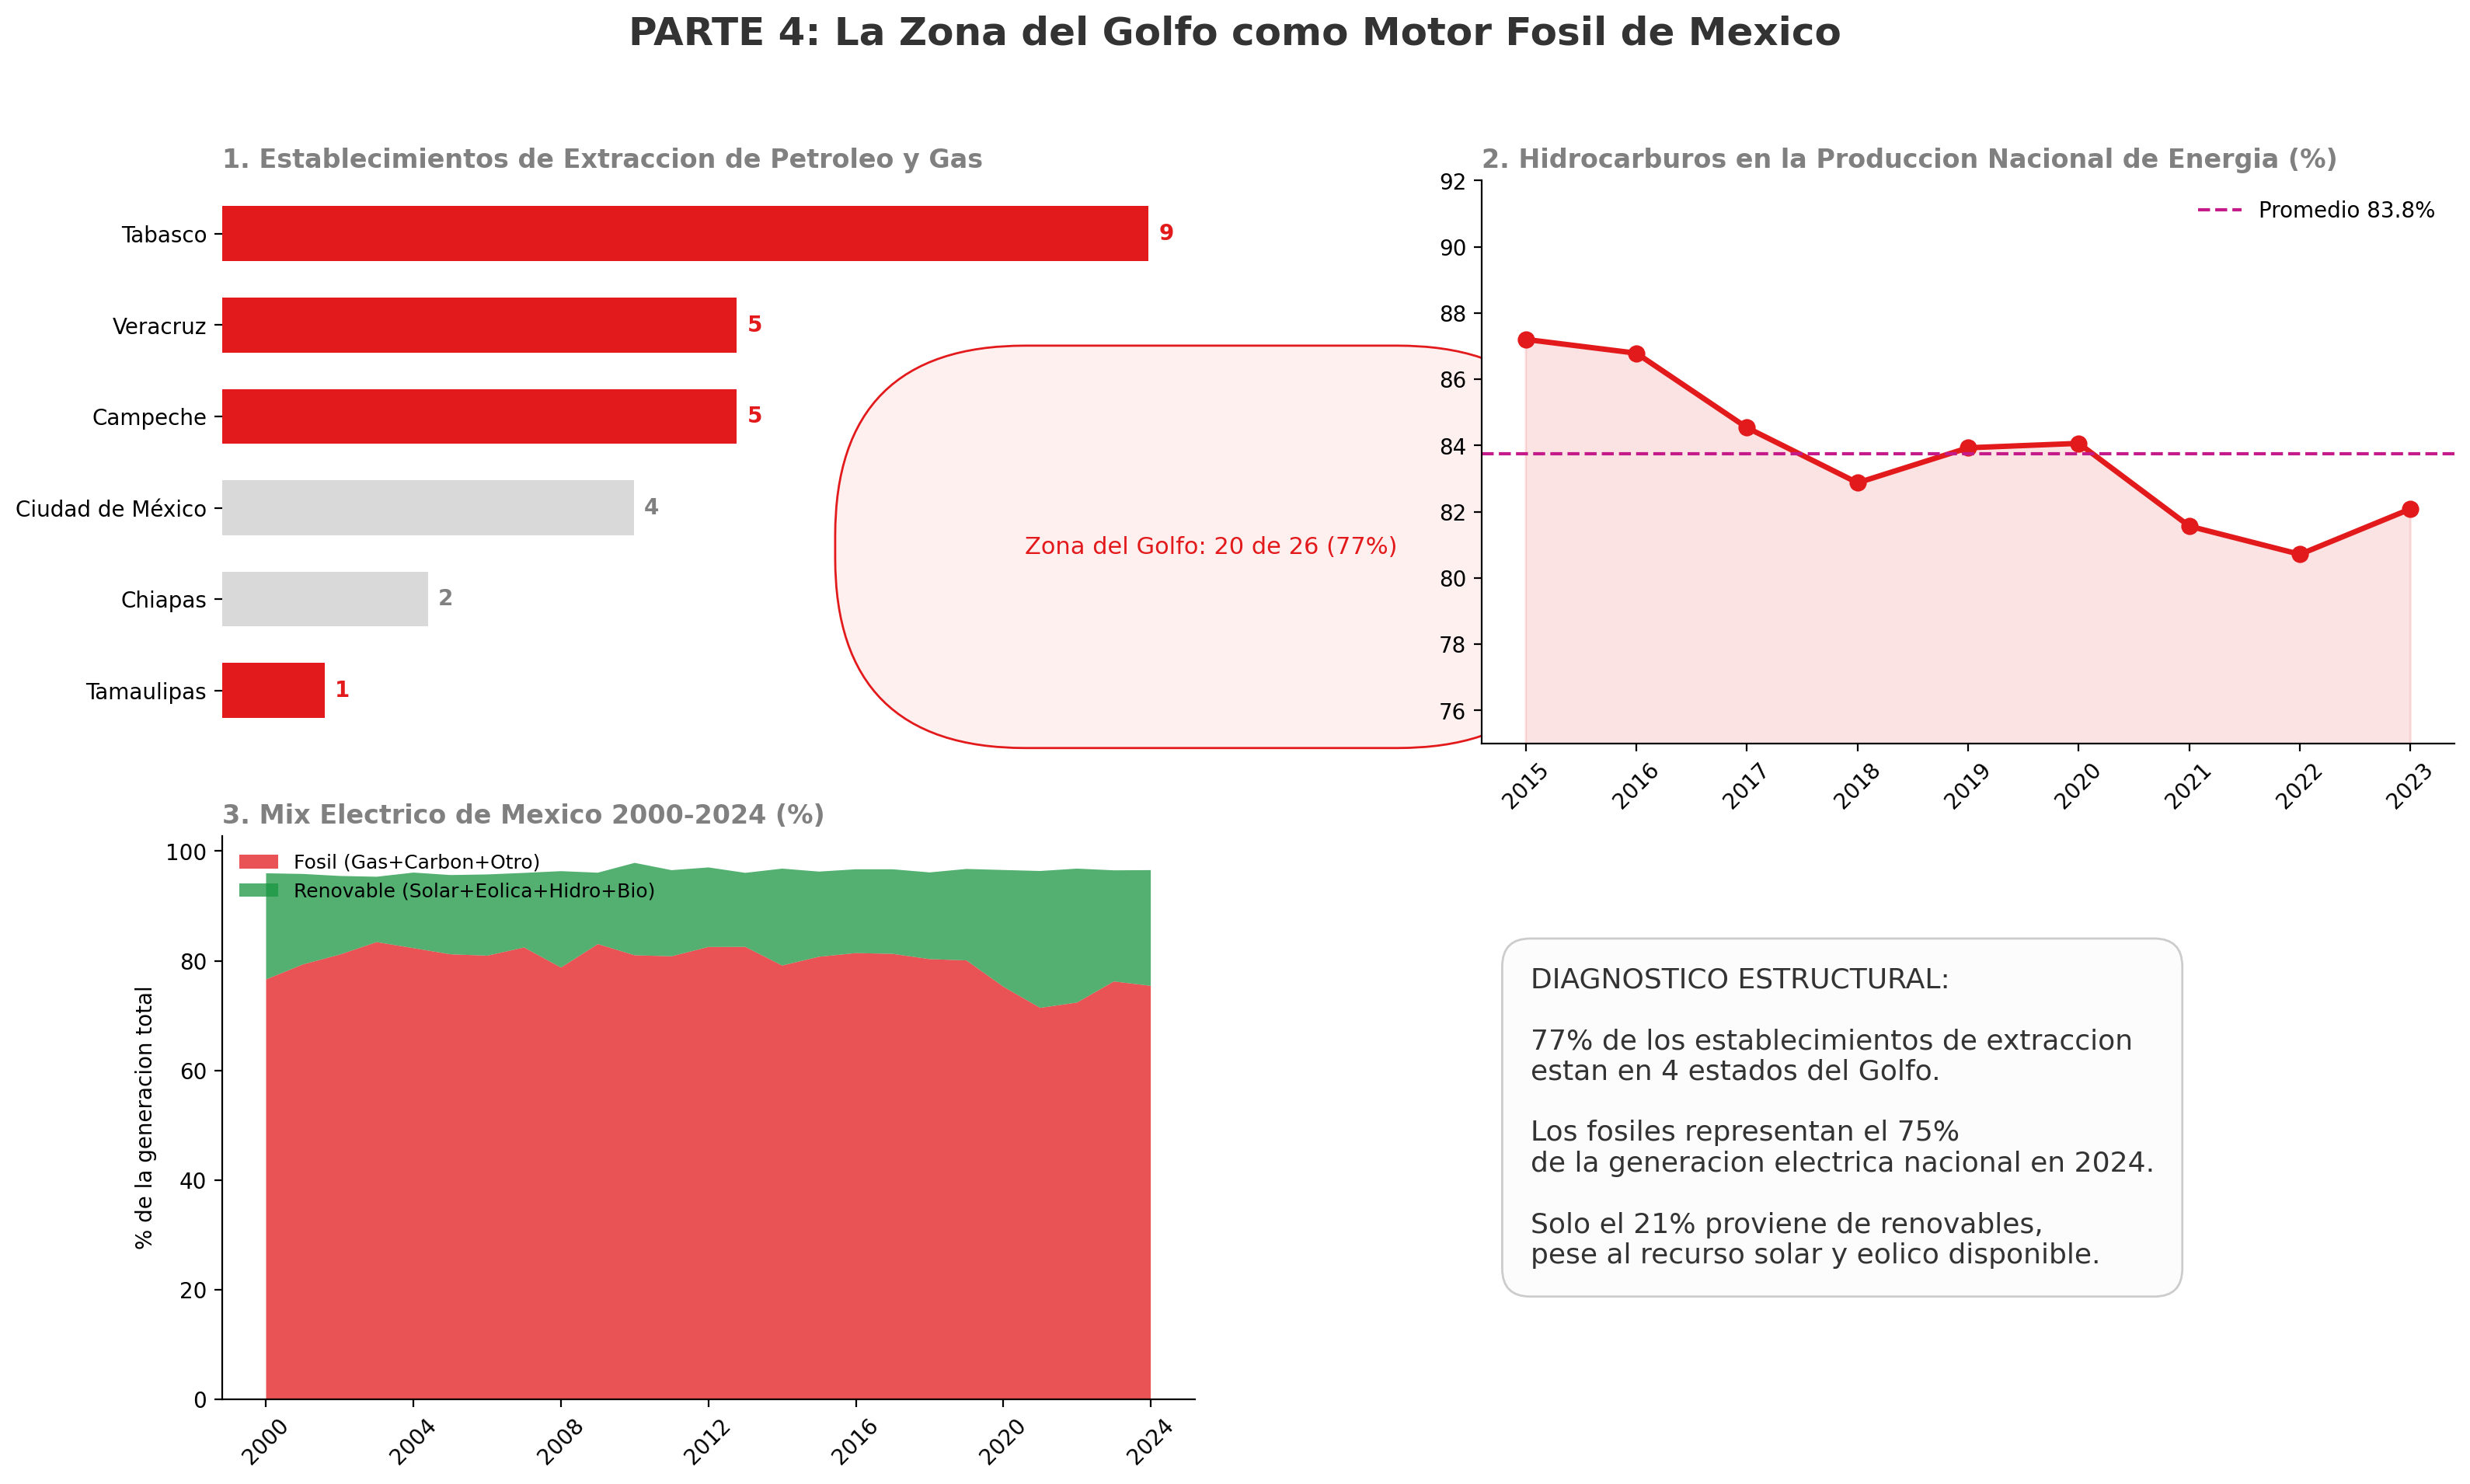

In [12]:
%config InlineBackend.figure_format = 'retina'
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PARTE 4: La Zona del Golfo como Motor Fosil de Mexico',
             fontsize=18, fontweight='bold', color='#333333')

# Panel 1: Establecimientos
df_s = dist.sort_values('Economic Unit', ascending=True)
colores_e = ['#e31a1c' if g else '#d9d9d9' for g in df_s['zona_golfo']]
axs[0,0].barh(df_s['estado'], df_s['Economic Unit'], color=colores_e, height=0.6)
axs[0,0].set_title('1. Establecimientos de Extraccion de Petroleo y Gas',
                   loc='left', color='gray', fontweight='bold')
axs[0,0].spines[['top','right','bottom','left']].set_visible(False)
axs[0,0].set_xticks([])
for i, v in enumerate(df_s['Economic Unit']):
    c = '#e31a1c' if df_s['zona_golfo'].iloc[i] else 'gray'
    axs[0,0].text(v + 0.1, i, str(v), va='center', fontweight='bold', color=c)
axs[0,0].text(7.8, 1.5, f'Zona del Golfo: {golfo_estab} de {total_estab} ({pct_golfo:.0f}%)',
              fontsize=11, color='#e31a1c',
              bbox=dict(facecolor='#fff0f0', edgecolor='#e31a1c', pad=8, boxstyle='round'))

# Panel 2: Participacion SENER
axs[0,1].fill_between(prod['anno'], prod['participacion'], color='#e31a1c', alpha=0.12)
axs[0,1].plot(prod['anno'], prod['participacion'],
              color='#e31a1c', linewidth=2.5, marker='o', markersize=7)
axs[0,1].axhline(promedio_prod, linestyle='--', color='#c51b8a', linewidth=1.5,
                 label=f'Promedio {promedio_prod:.1f}%')
axs[0,1].set_title('2. Hidrocarburos en la Produccion Nacional de Energia (%)',
                   loc='left', color='gray', fontweight='bold')
axs[0,1].spines[['top','right']].set_visible(False)
axs[0,1].set_ylim(75, 92)
axs[0,1].set_xticks(prod['anno']); axs[0,1].tick_params(axis='x', rotation=45)
axs[0,1].legend(frameon=False)

# Panel 3: Mix electrico Mexico (OWID)
axs[1,0].stackplot(mix['date'], mix['Fosil_%'], mix['Renovable_%'],
                   labels=['Fosil (Gas+Carbon+Otro)','Renovable (Solar+Eolica+Hidro+Bio)'],
                   colors=['#e31a1c','#1a9641'], alpha=0.75)
axs[1,0].set_title('3. Mix Electrico de Mexico 2000-2024 (%)',
                   loc='left', color='gray', fontweight='bold')
axs[1,0].spines[['top','right']].set_visible(False)
axs[1,0].set_ylabel('% de la generacion total')
axs[1,0].legend(frameon=False, loc='upper left', fontsize=9)
axs[1,0].set_xticks(range(2000,2025,4)); axs[1,0].tick_params(axis='x', rotation=45)

# Panel 4: Hallazgos
axs[1,1].axis('off')
txt = ('DIAGNOSTICO ESTRUCTURAL:\n\n'
       f'{pct_golfo:.0f}% de los establecimientos de extraccion\n'
       'estan en 4 estados del Golfo.\n\n'
       f'Los fosiles representan el {fosil_2024:.0f}%\n'
       'de la generacion electrica nacional en 2024.\n\n'
       f'Solo el {renov_2024:.0f}% proviene de renovables,\n'
       'pese al recurso solar y eolico disponible.')
axs[1,1].text(0.05, 0.5, txt, fontsize=13, va='center', ha='left',
              color='#333333',
              bbox=dict(facecolor='#fcfcfc', edgecolor='#cccccc',
                        pad=20, boxstyle='round,pad=1'))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
## Sección 5: Una Alternativa de Mediano Plazo — Energías Renovables

La región del Golfo tiene más recurso solar y eólico que Alemania, el mayor productor solar del mundo. No es falta de recurso: es falta de política.

In [13]:
solar_golfo  = solar[solar['region'] != 'Germany'].copy()
solar_ref    = solar[solar['region'] == 'Germany'].iloc[0]
eolico_golfo = eolico[eolico['region'] != 'China'].copy()
eolico_ref   = eolico[eolico['region'] == 'China'].iloc[0]
solar_mx     = elec_mx[elec_mx['series']=='Solar'][['date','generation_share_pct']].copy()
wind_mx      = elec_mx[elec_mx['series']=='Wind'][['date','generation_share_pct']].copy()
solar_2024   = solar_mx[solar_mx['date']==2024]['generation_share_pct'].values[0]
wind_2024    = wind_mx[wind_mx['date']==2024]['generation_share_pct'].values[0]
avg_pvout    = solar_golfo['PVOUT_kWh_kWp'].mean()
tam_viento   = eolico_golfo[eolico_golfo['region']=='Tamaulipas']['viento_mediana_ms'].values[0]
print('Solar y eolico listos.')

Solar y eolico listos.


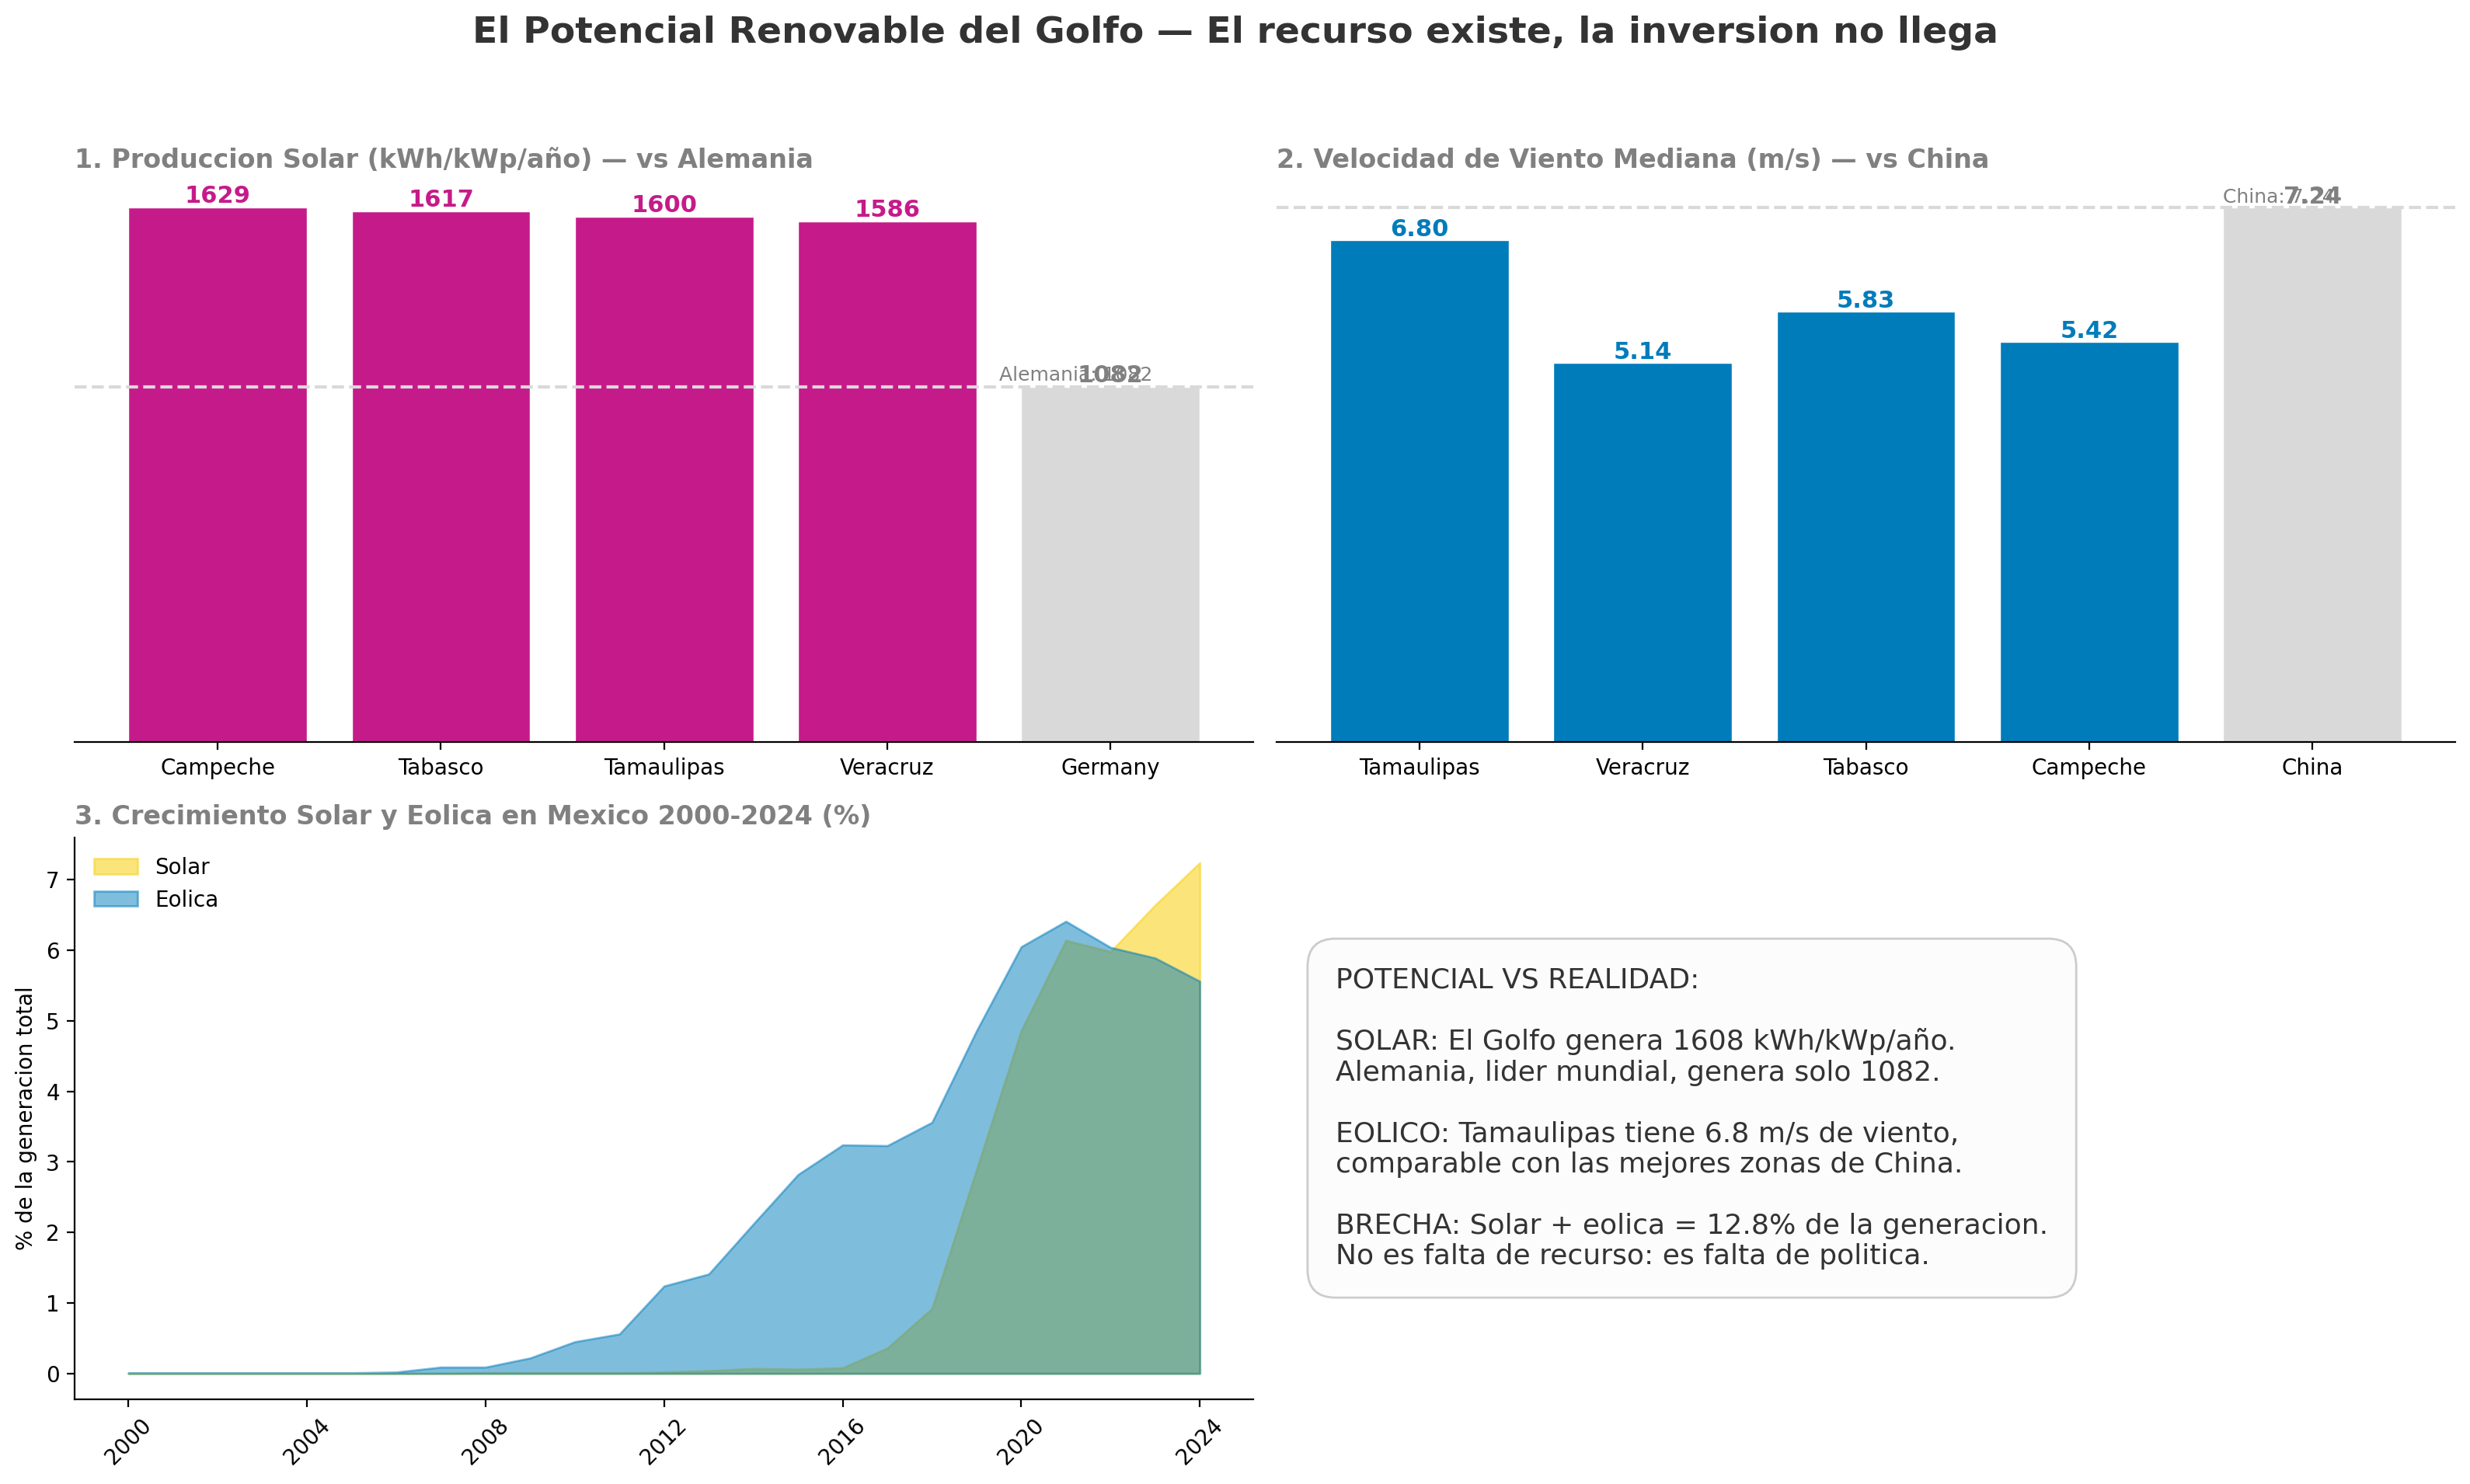

In [14]:
%config InlineBackend.figure_format = 'retina'
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('El Potencial Renovable del Golfo — El recurso existe, la inversion no llega',
             fontsize=17, fontweight='bold', color='#333333')

# Panel 1: Solar PVOUT vs Alemania
todos_solar = pd.concat([solar_golfo, solar[solar['region']=='Germany']])
colores_s   = ['#c51b8a' if r != 'Germany' else '#d9d9d9' for r in todos_solar['region']]
axs[0,0].bar(todos_solar['region'], todos_solar['PVOUT_kWh_kWp'],
             color=colores_s, edgecolor='white', linewidth=0.5)
axs[0,0].set_title('1. Produccion Solar (kWh/kWp/año) — vs Alemania',
                   loc='left', color='gray', fontweight='bold')
axs[0,0].spines[['top','right','left']].set_visible(False)
axs[0,0].set_yticks([])
for i, (r, v) in enumerate(zip(todos_solar['region'], todos_solar['PVOUT_kWh_kWp'])):
    c = '#c51b8a' if r != 'Germany' else 'gray'
    axs[0,0].text(i, v + 15, f'{v:.0f}', ha='center', fontweight='bold', color=c, fontsize=11)
axs[0,0].axhline(solar_ref['PVOUT_kWh_kWp'], linestyle='--', color='#d9d9d9', linewidth=1.5)
axs[0,0].text(3.5, solar_ref['PVOUT_kWh_kWp'] + 20,
              f'Alemania: {solar_ref["PVOUT_kWh_kWp"]:.0f}', fontsize=9, color='gray')

# Panel 2: Viento mediano vs China
todos_eol = pd.concat([eolico_golfo, eolico[eolico['region']=='China']])
colores_v  = ['#007CBB' if r != 'China' else '#d9d9d9' for r in todos_eol['region']]
axs[0,1].bar(todos_eol['region'], todos_eol['viento_mediana_ms'],
             color=colores_v, edgecolor='white', linewidth=0.5)
axs[0,1].set_title('2. Velocidad de Viento Mediana (m/s) — vs China',
                   loc='left', color='gray', fontweight='bold')
axs[0,1].spines[['top','right','left']].set_visible(False)
axs[0,1].set_yticks([])
for i, (r, v) in enumerate(zip(todos_eol['region'], todos_eol['viento_mediana_ms'])):
    c = '#007CBB' if r != 'China' else 'gray'
    axs[0,1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold', color=c, fontsize=11)
axs[0,1].axhline(eolico_ref['viento_mediana_ms'], linestyle='--', color='#d9d9d9', linewidth=1.5)
axs[0,1].text(3.6, eolico_ref['viento_mediana_ms'] + 0.06,
              f'China: {eolico_ref["viento_mediana_ms"]:.2f}', fontsize=9, color='gray')

# Panel 3: Crecimiento solar + eolica Mexico
axs[1,0].fill_between(solar_mx['date'], solar_mx['generation_share_pct'],
                       color='#f9d423', alpha=0.6, label='Solar')
axs[1,0].fill_between(wind_mx['date'], wind_mx['generation_share_pct'],
                       color='#007CBB', alpha=0.5, label='Eolica')
axs[1,0].set_title('3. Crecimiento Solar y Eolica en Mexico 2000-2024 (%)',
                   loc='left', color='gray', fontweight='bold')
axs[1,0].spines[['top','right']].set_visible(False)
axs[1,0].set_ylabel('% de la generacion total')
axs[1,0].legend(frameon=False)
axs[1,0].set_xticks(range(2000,2025,4)); axs[1,0].tick_params(axis='x', rotation=45)

# Panel 4: Conclusion
axs[1,1].axis('off')
txt = ('POTENCIAL VS REALIDAD:\n\n'
       f'SOLAR: El Golfo genera {avg_pvout:.0f} kWh/kWp/año.\n'
       f'Alemania, lider mundial, genera solo {solar_ref["PVOUT_kWh_kWp"]:.0f}.\n\n'
       f'EOLICO: Tamaulipas tiene {tam_viento:.1f} m/s de viento,\n'
       'comparable con las mejores zonas de China.\n\n'
       f'BRECHA: Solar + eolica = {solar_2024+wind_2024:.1f}% de la generacion.\n'
       'No es falta de recurso: es falta de politica.')
axs[1,1].text(0.05, 0.5, txt, fontsize=13, va='center', ha='left',
              color='#333333',
              bbox=dict(facecolor='#fcfcfc', edgecolor='#cccccc',
                        pad=20, boxstyle='round,pad=1'))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
## Sección 6: ¿Y ahora qué? — Llamados a la Acción

Los datos cuentan la historia. Pero los datos solos no mueven políticas ni cambian comunidades. Esta sección traduce los hallazgos en acciones concretas dirigidas a quienes tienen la responsabilidad y la capacidad de actuar.

### Para la Sociedad Civil y las Comunidades Costeras

**1. Documentar y denunciar sin parar.**  
Cada reporte ciudadano de chapopote en una playa es un dato que fortalece la exigencia legal y pública. El mapa de zonas de abandono depende de que las comunidades sigan reportando — las autoridades no siempre llegan solas.

**2. Organizar la economía local alrededor de lo que el mar sano puede dar.**  
El turismo sustentable, la pesca responsable y la acuicultura comunitaria son la única economía posible en zonas como Pajapan o Tatahuicapan si los hidrocarburos siguen contaminando el litoral. Las cooperativas y los fondos de reconversión productiva son urgentes.

**3. Exigir que el dinero del rescate llegue con perspectiva de género.**  
Los datos muestran que las mujeres pierden más empleo en zonas afectadas. Ningún programa de apoyo post-derrame es justo si no parte de esa realidad.

**4. Conectar la crisis del Golfo con el debate energético nacional.**  
Lo que pasó en 2026 no es un problema local: es el costo de que todo el país dependa de cuatro estados para encender la luz. Las comunidades afectadas tienen voz legítima en ese debate.

### Para el Gobierno Federal y los Gobiernos Estatales

**1. Activar fondos de emergencia con criterios territoriales y de género.**  
Coatzacoalcos tiene la mayor tasa de desempleo y la mayor concentración de reportes de chapopote. No puede recibir el mismo trato que zonas no afectadas. La asignación de recursos debe ser proporcional al impacto documentado.

**2. Establecer un régimen de responsabilidad real para la industria petrolera.**  
Cada barril derramado tiene un costo en empleos, salud y ecosistema. Hoy ese costo lo absorben las comunidades y el erario. Se necesita un fondo de contingencia obligatorio financiado por las empresas.

**3. Abrir la inversión en renovables en el Golfo — no solo hablar de ello.**  
Tamaulipas tiene vientos comparables con China. Campeche y Veracruz tienen más radiación solar que Alemania. La infraestructura de transmisión ya existe porque se construyó para los hidrocarburos — reutilizarla para conectar parques solares y eólicos es viable hoy.  
Mientras solar y eólica representen menos del 13% de la generación nacional, el riesgo de concentración no desaparece.

**4. Diseñar una transición justa para trabajadores del sector fósil.**  
Los empleos en hidrocarburos del Golfo no pueden desaparecer sin una ruta de conversión. Programas de capacitación para instalación y mantenimiento de plantas renovables, con prioridad para trabajadores de la zona, son la diferencia entre una transición que divide y una que integra.

**5. Publicar datos abiertos y actualizados sobre el derrame.**  
Este análisis fue posible gracias a datos abiertos de INEGI, SENER, OWID, Global Solar Atlas y Global Wind Atlas. Los datos específicos sobre el derrame de 2026 aún son escasos. La transparencia no es opcional en una crisis de esta escala.

### En Síntesis

| ¿Quién? | ¿Qué hacer? | ¿Para cuándo? |
|---|---|---|
| Comunidades costeras | Reportar, organizarse, exigir con datos | Inmediato |
| Gobierno federal | Fondos de emergencia diferenciados por impacto | 90 días |
| Gobiernos estatales (Golfo) | Licencias para proyectos renovables en zonas aptas | 2026–2027 |
| Industria petrolera | Fondo de contingencia obligatorio por derrame | Con reforma |
| Sector energético | Transición laboral fósil → renovable en el Golfo | 2026–2030 |

---
*El Golfo de México no merece ser el costo oculto del desarrollo energético de México.*  
*Sus comunidades, su biodiversidad y su potencial renovable merecen estar al centro de la política energética — no en los márgenes.*

---
*Análisis: SamsanTech · HackODS 2026*  
*Fuentes: SENER · INEGI ENOE · Our World in Data · Global Solar Atlas · Global Wind Atlas · Reportes ciudadanos*